In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [14]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')


Số ảnh train: 60000,  test: 10000


**Kiến trúc model**

Input  (1, 28, 28)
  
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  
  │ Flatten → 800
  
  │
FC (800 → 10) → logits

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến nn.Linear sai chiều và chương trình lỗi shape mismatch.

In [15]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

**Huấn luyện**

Tracking đúng cách: cộng dồn loss theo số mẫu, không theo số batch (vì batch cuối có thể nhỏ hơn).

In [17]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1825  train_acc=94.30%  test_loss=0.0628  test_acc=97.93%
Epoch 2/5  train_loss=0.0649  train_acc=98.06%  test_loss=0.0563  test_acc=98.13%
Epoch 3/5  train_loss=0.0494  train_acc=98.50%  test_loss=0.0410  test_acc=98.70%
Epoch 4/5  train_loss=0.0422  train_acc=98.69%  test_loss=0.0496  test_acc=98.52%
Epoch 5/5  train_loss=0.0370  train_acc=98.80%  test_loss=0.0415  test_acc=98.62%


Đổi epoch từ 5 -> 10


In [18]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/10  train_loss=0.0315  train_acc=99.06%  test_loss=0.0327  test_acc=98.93%
Epoch 2/10  train_loss=0.0281  train_acc=99.10%  test_loss=0.0360  test_acc=98.90%
Epoch 3/10  train_loss=0.0251  train_acc=99.18%  test_loss=0.0369  test_acc=98.85%
Epoch 4/10  train_loss=0.0223  train_acc=99.28%  test_loss=0.0359  test_acc=98.86%
Epoch 5/10  train_loss=0.0203  train_acc=99.31%  test_loss=0.0358  test_acc=98.95%
Epoch 6/10  train_loss=0.0181  train_acc=99.44%  test_loss=0.0306  test_acc=99.02%
Epoch 7/10  train_loss=0.0168  train_acc=99.45%  test_loss=0.0345  test_acc=99.02%
Epoch 8/10  train_loss=0.0157  train_acc=99.50%  test_loss=0.0327  test_acc=98.96%
Epoch 9/10  train_loss=0.0128  train_acc=99.59%  test_loss=0.0348  test_acc=98.96%
Epoch 10/10  train_loss=0.0121  train_acc=99.62%  test_loss=0.0338  test_acc=99.01%


Câu1

*   Test accuracy của epoch =5 là 98.62%
*   Test accuracy của epoch =5 là 99.01%

-->trên nhau 0.39%


Khoảng cách train_acc - test_acc: có sự mở rộng khoảng 0.61%

Đây là dấu hiệu của overfitting



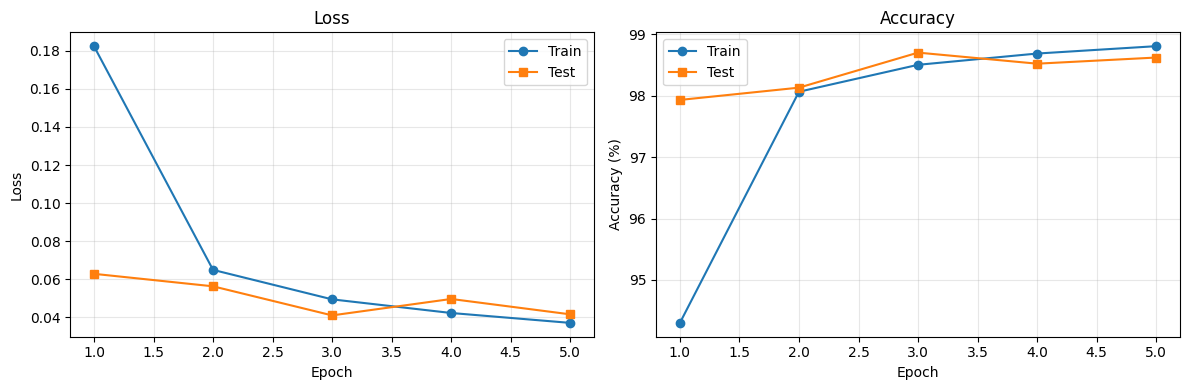

In [7]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

Đánh giá trên test set

In [8]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.62%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


Trực quan: model dự đoán

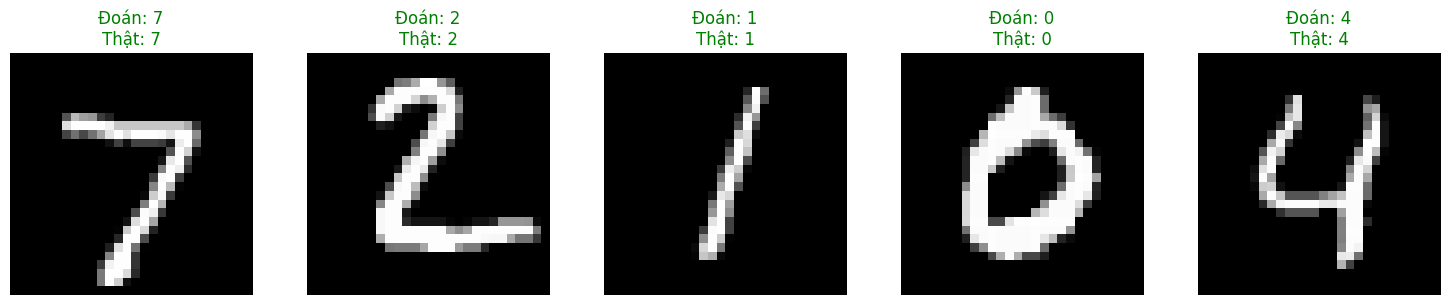

In [10]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

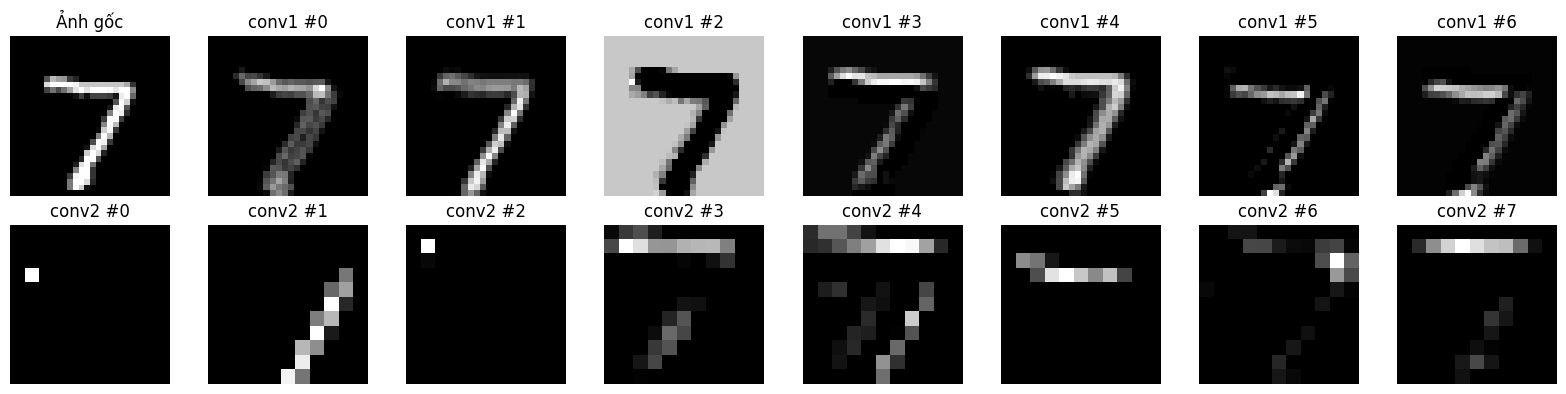

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [11]:

model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')